# Synthetic Control in Practice

**Course**: Quantitative Econometrics  
**Topic**: Practical synthetic control  
**Applications**: California Proposition 99 and German reunification

This notebook emphasizes transparent counterfactual construction. Instead of hiding the method inside one black-box function call, we will:

1. load two canonical synthetic-control datasets,
2. visualize treated and donor trajectories,
3. estimate donor weights with simplex constraints,
4. compare the treated path to its synthetic counterpart,
5. inspect the treatment-effect gap and the weight concentration.

## Setup

The helper module uses:

- local tabular files placed in `lectures/code/data/`,
- `scipy.optimize.minimize` to solve the synthetic-control weight problem,
- `matplotlib` and `seaborn` for visualization.

For reliability, place the California and Germany datasets in `lectures/code/data/` before running the notebook. A short note in that folder lists the accepted filenames and column names.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

candidate_dirs = [Path.cwd(), Path.cwd() / "lectures" / "code"]
for candidate in candidate_dirs:
    if (candidate / "panel_policy_lab.py").exists():
        sys.path.insert(0, str(candidate))
        break

import panel_policy_lab as lab

lab.set_plot_style()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## Example 1: California Proposition 99

This is the classic Abadie, Diamond, and Hainmueller application. California imposes a tobacco-control intervention in 1989. The empirical question is whether post-1989 cigarette consumption departs from a credible synthetic counterfactual built from untreated states.

In [2]:
california = lab.load_california_prop99()

summary_ca = pd.DataFrame(
    {
        "Statistic": ["Rows", "States", "First year", "Last year"],
        "Value": [
            len(california),
            california["State"].nunique(),
            california["Year"].min(),
            california["Year"].max(),
        ],
    }
)

display(summary_ca)
display(california.head())

,Statistic,Value
0,Rows,1209
1,States,39
2,First year,1970
3,Last year,2000


,State,Year,PacksPerCapita,treated
0,Alabama,1970,89.800,0
1,Arkansas,1970,100.300,0
2,Colorado,1970,124.800,0
3,Connecticut,1970,120.000,0
4,Delaware,1970,155.000,0


### Step 1. Raw trajectories

Always begin by looking at the treated unit against the donor pool. The point is not to eyeball the answer, but to see whether California looks structurally unusual even before estimation.

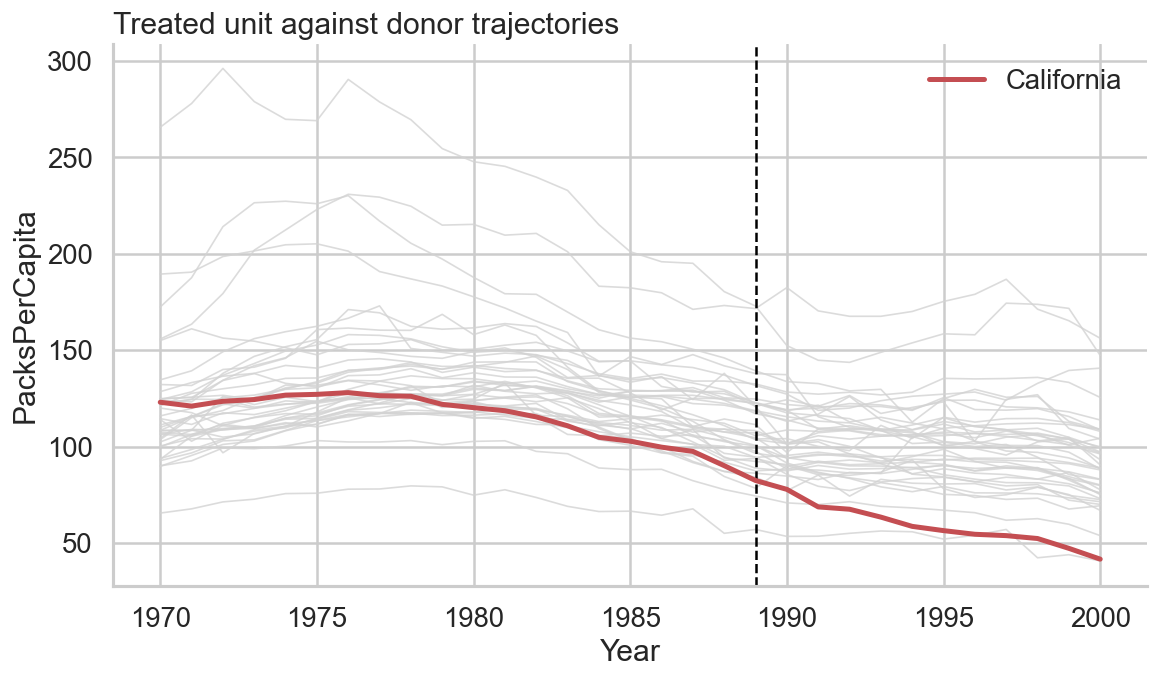

In [3]:
lab.plot_donor_spaghetti(
    california,
    unit_col="State",
    time_col="Year",
    outcome_col="PacksPerCapita",
    treated_unit="California",
    treatment_start=1989,
)

### Step 2. Fit the synthetic control

In this notebook, the synthetic control is estimated from the pre-treatment outcome path itself. That is often an instructive starting point because lagged outcomes already summarize a great deal of what matters for untreated evolution.

The weights are constrained to be nonnegative and sum to one.

,unit,weight
0,Utah,0.385
1,Montana,0.271
2,Nevada,0.186
3,Connecticut,0.080
4,New Hampshire,0.049
5,Colorado,0.030
6,Wyoming,0.000
7,Vermont,0.000
8,Tennessee,0.000
9,Georgia,0.000


{'optimization_success': True, 'objective_value': 0.05786517544385384}


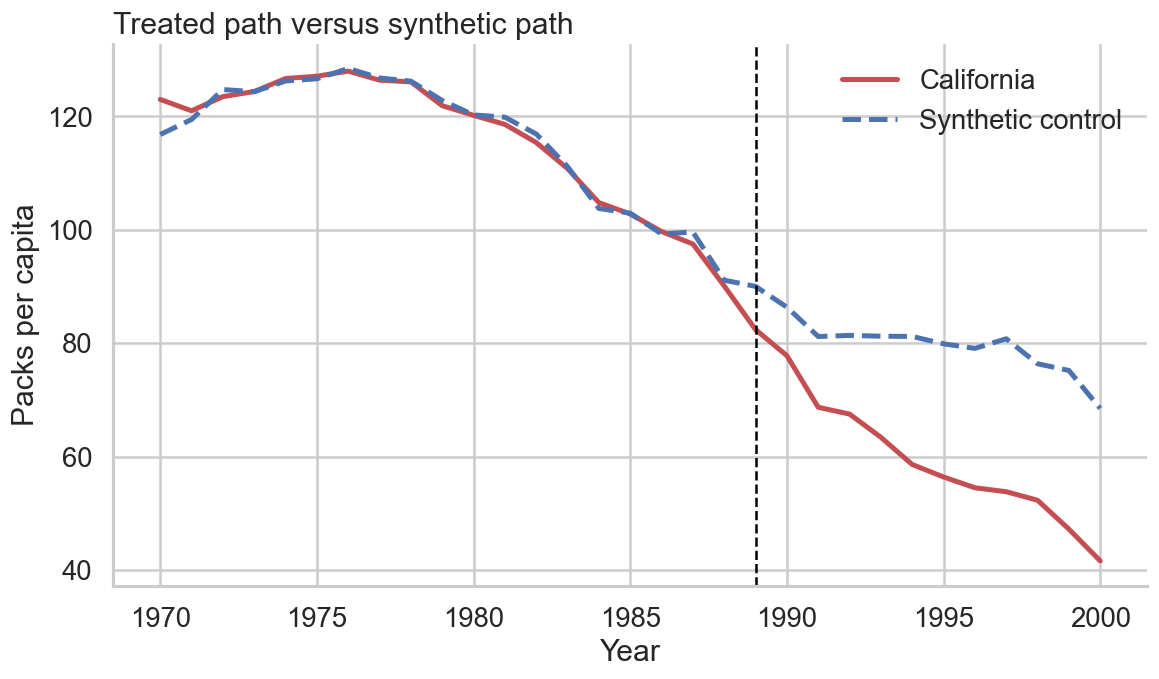

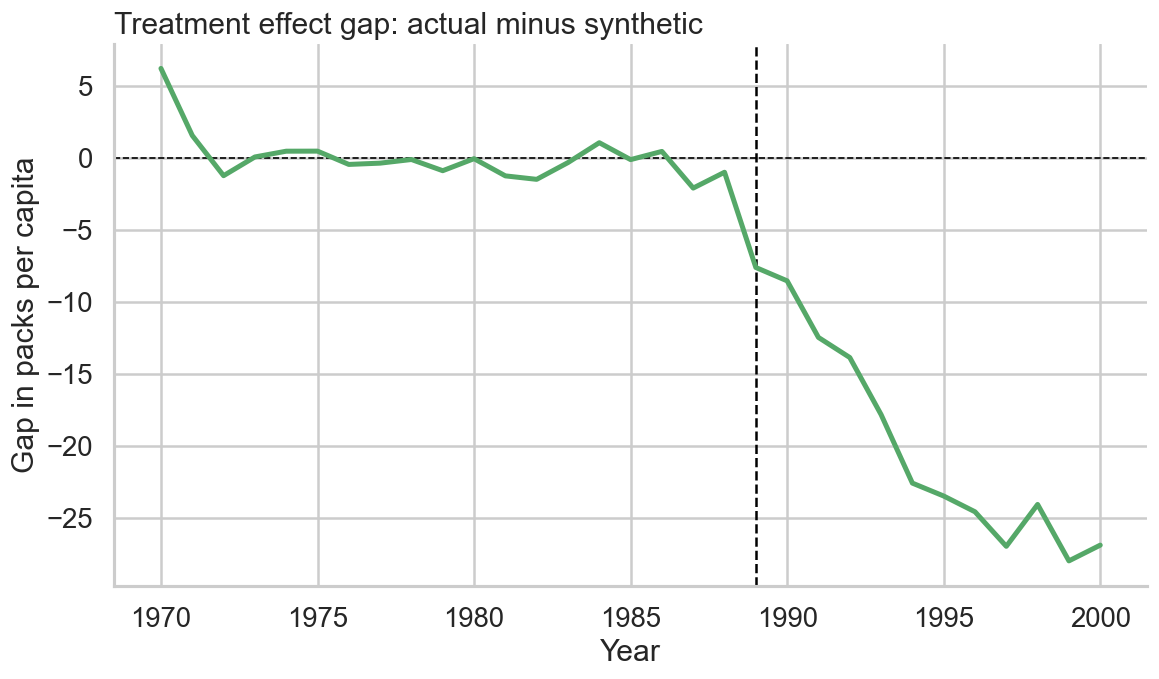

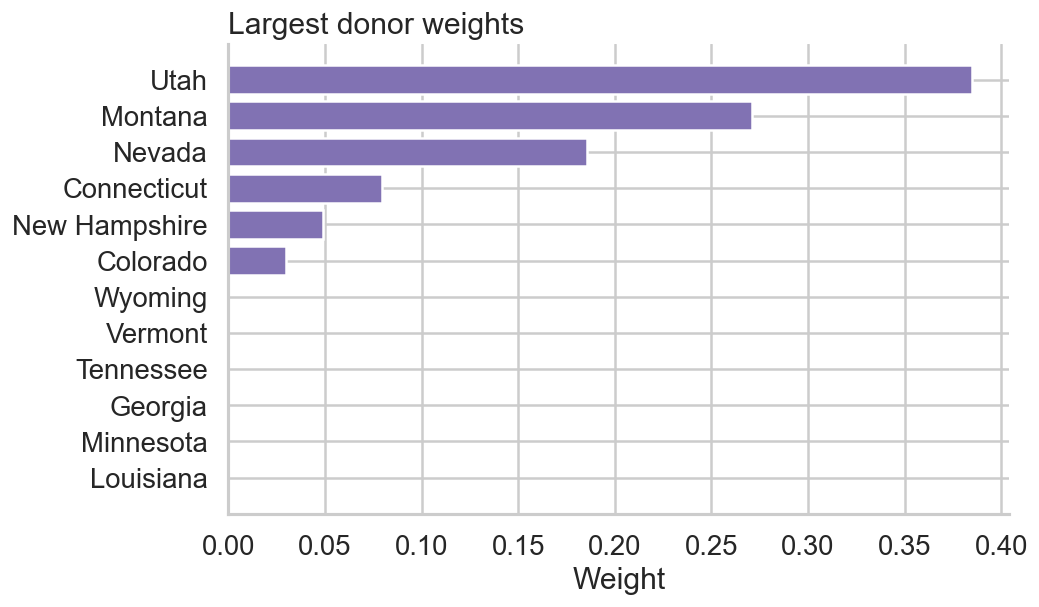

In [4]:
ca_result = lab.fit_synthetic_control(
    california,
    unit_col="State",
    time_col="Year",
    outcome_col="PacksPerCapita",
    treated_unit="California",
    treatment_start=1989,
)

display(ca_result.weights.head(10))
print({
    "optimization_success": ca_result.optimization_success,
    "objective_value": ca_result.objective_value,
})

lab.plot_synth_paths(ca_result, "Packs per capita")
lab.plot_synth_gap(ca_result, "packs per capita")
lab.plot_top_weights(ca_result, top_n=12)

### Interpretation prompt

Ask three questions before treating the gap as causal:

1. Is pre-treatment fit actually close?  
2. Are the donor weights economically plausible, or is one donor carrying almost everything?  
3. Could another shock in California around 1989 explain the divergence?

## Example 2: German reunification

Now move to one of the other canonical synthetic-control applications: West Germany after reunification. Here the outcome is GDP per capita, and the treated unit is compared to a synthetic combination of other OECD countries.

This example is useful because it brings out a different economic scale: national macro history rather than state-level policy.

In [5]:
germany = lab.load_germany_reunification()

summary_de = pd.DataFrame(
    {
        "Statistic": ["Rows", "Countries", "First year", "Last year"],
        "Value": [
            len(germany),
            germany["country"].nunique(),
            germany["year"].min(),
            germany["year"].max(),
        ],
    }
)

display(summary_de)
display(germany.head())

RuntimeError: Could not find a local German reunification dataset. Place scpi_germany.csv or germany_reunification.csv in lectures/code/data/.

### Step 1. Visualize the treated unit among donors

Again, start with the raw trajectories. West Germany is a distinctive economy, so the donor support question matters immediately.

In [ ]:
lab.plot_donor_spaghetti(
    germany,
    unit_col="country",
    time_col="year",
    outcome_col="gdp",
    treated_unit="West Germany",
    treatment_start=1990,
)

### Step 2. Estimate the synthetic control

For the Germany example, we enrich the pre-treatment matching problem when those covariates are available in the local file. If they are absent, the notebook falls back to outcome-path matching alone.

In [ ]:
candidate_features = ["trade", "schooling", "industry", "infrate"]
available_features = [col for col in candidate_features if col in germany.columns]
print({"feature_cols_used": available_features})

de_result = lab.fit_synthetic_control(
    germany,
    unit_col="country",
    time_col="year",
    outcome_col="gdp",
    treated_unit="West Germany",
    treatment_start=1990,
    feature_cols=available_features,
)

display(de_result.weights.head(10))
print({
    "optimization_success": de_result.optimization_success,
    "objective_value": de_result.objective_value,
})

lab.plot_synth_paths(de_result, "GDP per capita")
lab.plot_synth_gap(de_result, "GDP per capita")
lab.plot_top_weights(de_result, top_n=10)

## What students should notice

- Synthetic control is a method for constructing a comparison unit, not just estimating a coefficient.  
- The first question is always whether pre-treatment fit is convincing.  
- The second question is whether the donor weights make economic sense.  
- California and Germany are useful to teach together because one is a state policy application and the other is a macro historical application, but the design logic is the same.

## Suggested extensions

1. Refit California after excluding the largest donor state and compare the gap.  
2. Refit Germany using only the outcome path, then compare it to the feature-augmented version.  
3. Standardize the outcome before fitting and check whether weight concentration changes.  
4. Add placebo loops donor by donor and build a rank-style diagnostic plot.